# Session 03 Practical Activity: Data Cleaning and Preprocessing

**Goal:** Clean a messy CSV and produce before/after diagnostics using Pandas, NumPy, Matplotlib, and Seaborn.

You will practise:
- identifying missing values, duplicates, outliers, and invalid ranges;
- separating categorical and numerical variables;
- cleaning categories;
- encoding and scaling features;
- documenting decisions in a reproducible notebook.

In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
DATA_PATH = Path('data/raw/uk_workplace_data_cleaning_messy_dataset.csv')

## 1. Load the messy CSV

A professional cleaning workflow starts with basic inspection. Do not clean anything before you understand the shape, columns, and obvious quality issues.

In [29]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print('Shape:', df.shape)
df.head()

Shape: (620, 14)


,learner_id,department,region,role_family,employee_band,training_type,enrolment_date,prior_python_score,course_minutes,engagement_score,manager_support_score,support_tickets_last_30d,completion_days,completed_on_time
0,L10387,OPERATIONS,Remote,Technician,A,ML Foundations,2026-02-15,41.9,189.8,91.3,4.0,1,20.0,1
1,L10089,Sales,Unknown,Associate,A,ML Foundations,2026-02-07,39.6,191.8,84.7,NaN,1,23.0,1
2,L10448,operations,Manchester,Analyst,B,AI Awareness,2026-03-10,36.1,93.6,100.0,1.0,3,13.0,1
3,L10599,Human Resources,Manchester,Technician,C,AI Awareness,2026-01-05,55.7,186.0,37.1,4.0,4,8.0,0
4,L10227,IT,Edinburgh,Coordinator,B,Data Literacy,2026-03-08,10.6,237.5,47.9,1.0,1,15.0,0


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   learner_id                620 non-null    str    
 1   department                602 non-null    str    
 2   region                    596 non-null    str    
 3   role_family               620 non-null    str    
 4   employee_band             620 non-null    str    
 5   training_type             620 non-null    str    
 6   enrolment_date            620 non-null    str    
 7   prior_python_score        585 non-null    float64
 8   course_minutes            620 non-null    float64
 9   engagement_score          590 non-null    float64
 10  manager_support_score     606 non-null    float64
 11  support_tickets_last_30d  620 non-null    str    
 12  completion_days           602 non-null    float64
 13  completed_on_time         620 non-null    int64  
dtypes: float64(5), int64(

## 2. Create a before-cleaning diagnostic summary

This gives you a baseline so that you can later prove what changed.

In [31]:
def diagnostic_summary(dataframe):
    summary = pd.DataFrame({
        'dtype': dataframe.dtypes.astype(str),
        'missing_count': dataframe.isna().sum(),
        'missing_pct': (dataframe.isna().mean() * 100).round(2),
        'unique_values': dataframe.nunique(dropna=True)
    })
    return summary.sort_values('missing_pct', ascending=False)

before_summary = diagnostic_summary(df)
before_summary

,dtype,missing_count,missing_pct,unique_values
prior_python_score,float64,35,5.65,373
engagement_score,float64,30,4.84,367
region,str,24,3.87,11
completion_days,float64,18,2.90,32
department,str,18,2.90,13
manager_support_score,float64,14,2.26,5
training_type,str,0,0.00,5
employee_band,str,0,0.00,4
role_family,str,0,0.00,6
learner_id,str,0,0.00,600


In [32]:
exact_duplicates = df.duplicated().sum()
print('Exact duplicate rows:', exact_duplicates)

Exact duplicate rows: 20


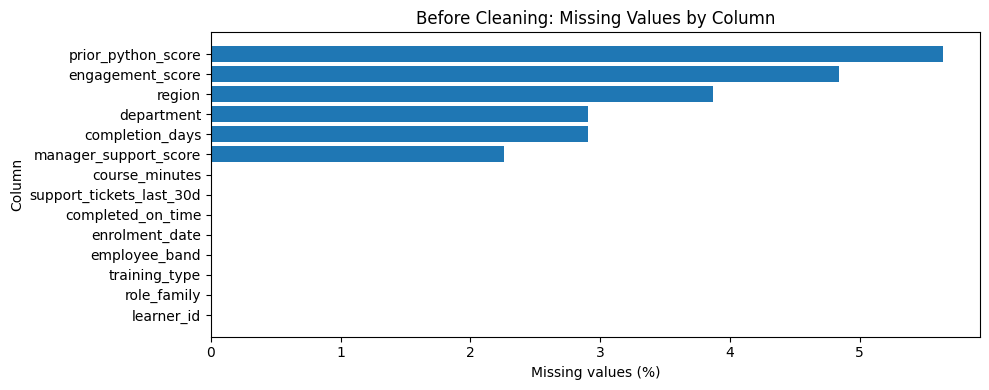

In [33]:
plt.figure(figsize=(10, 4))
missing_pct = (df.isna().mean() * 100).sort_values(ascending=True)
plt.barh(missing_pct.index.astype(str), missing_pct.values)
plt.title('Before Cleaning: Missing Values by Column')
plt.xlabel('Missing values (%)')
plt.ylabel('Column')
plt.tight_layout()
plt.savefig('visuals/missing_values_by_column.png', dpi=150)
plt.show()

## 3. Convert obvious numeric columns safely

Some counts are stored as text, such as `3 tickets`. We extract the numeric part and convert it to a number.

In [34]:
df['support_tickets_last_30d'] = (
    df['support_tickets_last_30d']
      .astype(str)
      .str.extract(r'(\d+)')[0]
      .astype(float)
)

## 4. Standardise categorical variables

Category cleanup prevents the model from treating `REMOTE`, `remote`, and `remote ` as different groups.

In [36]:
def clean_text_category(series):
    return (
        series.astype('string')
              .str.strip()
              .str.lower()
              .replace({'<NA>': pd.NA, 'nan': pd.NA})
    )

for col in ['department', 'region', 'role_family', 'employee_band', 'training_type']:
    df[col] = clean_text_category(df[col])

# Map known category synonyms
membership = {
    'human resources': 'hr',
    'information technology': 'it',
    'support': 'customer support',
    'operations': 'operations',
    'finance': 'finance',
    'sales': 'sales'
}
df['department'] = df['department'].replace(membership)
df['region'] = df['region'].replace({'remote': 'remote', 'unknown': pd.NA})

df[['department', 'region', 'training_type']].head()

,department,region,training_type
0,operations,remote,ml foundations
1,sales,<NA>,ml foundations
2,operations,manchester,ai awareness
3,hr,manchester,ai awareness
4,it,edinburgh,data literacy


## 5. Parse dates and flag invalid values

In a production workflow, invalid dates should be investigated. In this training dataset, we convert invalid dates to missing values and create a flag.

In [37]:
df['enrolment_date_parsed'] = pd.to_datetime(df['enrolment_date'], errors='coerce', dayfirst=True)
df['enrolment_date_invalid_flag'] = df['enrolment_date_parsed'].isna().astype(int)
df[['enrolment_date', 'enrolment_date_parsed', 'enrolment_date_invalid_flag']].head(10)

C:\Users\Chloe\AppData\Local\Temp\ipykernel_49676\254819253.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['enrolment_date_parsed'] = pd.to_datetime(df['enrolment_date'], errors='coerce', dayfirst=True)


,enrolment_date,enrolment_date_parsed,enrolment_date_invalid_flag
0,2026-02-15,2026-02-15,0
1,2026-02-07,2026-02-07,0
2,2026-03-10,2026-03-10,0
3,2026-01-05,2026-01-05,0
4,2026-03-08,2026-03-08,0
5,2026-01-28,2026-01-28,0
6,2026-03-28,2026-03-28,0
7,2026-03-01,2026-03-01,0
8,07/01/2026,NaT,1
9,2026-03-31,2026-03-31,0


## 6. Handle impossible numeric ranges

Cleaning should preserve signal. Instead of deleting rows immediately, first convert impossible values to missing and create flags.

In [38]:
range_rules = {
    'prior_python_score': (0, 100),
    'engagement_score': (0, 100),
    'course_minutes': (0, 480),
    'manager_support_score': (1, 5),
    'support_tickets_last_30d': (0, 50),
    'completion_days': (0, 120)
}

for col, (low, high) in range_rules.items():
    invalid = ~df[col].between(low, high) & df[col].notna()
    df[f'{col}_invalid_flag'] = invalid.astype(int)
    df.loc[invalid, col] = np.nan

invalid_flag_cols = [c for c in df.columns if c.endswith('_invalid_flag')]
df[invalid_flag_cols].sum().sort_values(ascending=False)

enrolment_date_invalid_flag              11
prior_python_score_invalid_flag           6
course_minutes_invalid_flag               6
engagement_score_invalid_flag             5
manager_support_score_invalid_flag        0
support_tickets_last_30d_invalid_flag     0
completion_days_invalid_flag              0
dtype: int64

## 7. Handle missing values with explicit decisions

For this short activity:
- numerical columns use median imputation;
- categorical columns use `unknown`;
- flags preserve the fact that values were missing or invalid.

In a real modelling pipeline, imputation should be fitted on the training set only.

In [39]:
numeric_cols = ['prior_python_score', 'course_minutes', 'engagement_score',
                'manager_support_score', 'support_tickets_last_30d', 'completion_days']
categorical_cols = ['department', 'region', 'role_family', 'employee_band', 'training_type']

for col in numeric_cols:
    df[f'{col}_missing_flag'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[f'{col}_missing_flag'] = df[col].isna().astype(int)
    df[col] = df[col].fillna('unknown')

## 8. Remove exact duplicate rows

Exact duplicates can overweight a record. We remove exact duplicate rows after standardising obvious formats.

In [41]:
rows_before = len(df)
df = df.drop_duplicates(ignore_index=True)
rows_after = len(df)
print('Rows before:', rows_before)
print('Rows after:', rows_after)
print('Rows removed:', rows_before - rows_after)

Rows before: 600
Rows after: 600
Rows removed: 0


## 9. Review outliers using a boxplot

A boxplot helps reveal extreme values. Outliers are not automatically wrong; they need judgement.

C:\Users\Chloe\AppData\Local\Temp\ipykernel_49676\1995633454.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in plot_cols], labels=plot_cols)


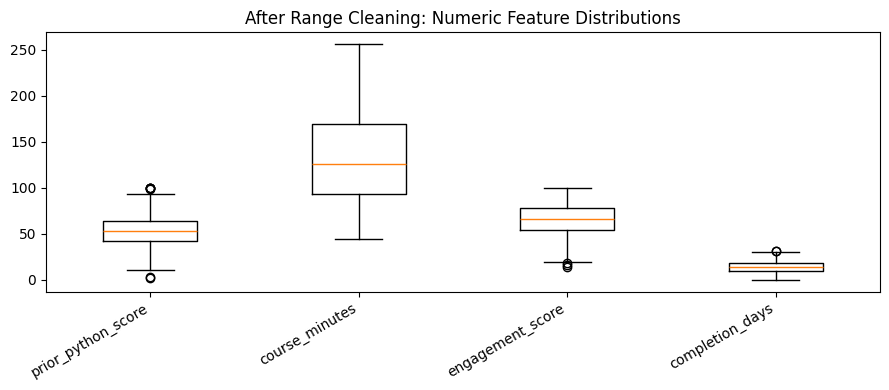

In [42]:
plt.figure(figsize=(9, 4))
plot_cols = ['prior_python_score', 'course_minutes', 'engagement_score', 'completion_days']
plt.boxplot([df[col].dropna() for col in plot_cols], labels=plot_cols)
plt.title('After Range Cleaning: Numeric Feature Distributions')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('visuals/outlier_boxplot.png', dpi=150)
plt.show()

## 10. Scale numerical variables and encode categories

For this session we use Pandas/NumPy only. Later modelling sessions will use formal preprocessing pipelines.

In [19]:
# Z-score scaling using NumPy/Pandas
for col in ['prior_python_score', 'course_minutes', 'engagement_score', 'support_tickets_last_30d']:
    std = df[col].std(ddof=0)
    df[f'{col}_zscore'] = 0 if std == 0 else (df[col] - df[col].mean()) / std

# One-hot encode selected categorical variables
encoded = pd.get_dummies(df[['department', 'region', 'training_type']], prefix=['dept', 'region', 'training'], dtype=int)
model_ready = pd.concat([df, encoded], axis=1)
model_ready.head()

,learner_id,department,region,role_family,employee_band,training_type,enrolment_date,prior_python_score,course_minutes,engagement_score,manager_support_score,support_tickets_last_30d,completion_days,completed_on_time,enrolment_date_parsed,enrolment_date_invalid_flag,prior_python_score_invalid_flag,engagement_score_invalid_flag,course_minutes_invalid_flag,manager_support_score_invalid_flag,support_tickets_last_30d_invalid_flag,completion_days_invalid_flag,prior_python_score_missing_flag,course_minutes_missing_flag,engagement_score_missing_flag,...,prior_python_score_zscore,course_minutes_zscore,engagement_score_zscore,support_tickets_last_30d_zscore,dept_customer support,dept_finance,dept_hr,dept_it,dept_operations,dept_sales,dept_unknown,region_birmingham,region_bristol,region_cardiff,region_edinburgh,region_leeds,region_london,region_manchester,region_remote,region_unknown,training_ai awareness,training_data literacy,training_ml foundations,training_python basics,training_responsible ai
0,L10387,operations,remote,technician,a,ml foundations,2026-02-15,41.9,189.8,91.3,4.0,1.0,20.0,1,2026-02-15,0,0,0,0,0,0,0,0,0,0,...,-0.653254,1.143800,1.432526,-0.798179,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
1,L10089,sales,unknown,associate,a,ml foundations,2026-02-07,39.6,191.8,84.7,3.0,1.0,23.0,1,2026-02-07,0,0,0,0,0,0,0,0,0,0,...,-0.788438,1.184073,1.059953,-0.798179,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
2,L10448,operations,manchester,analyst,b,ai awareness,2026-03-10,36.1,93.6,100.0,1.0,3.0,13.0,1,2026-03-10,0,0,0,0,0,0,0,0,0,0,...,-0.994154,-0.793331,1.923645,0.606242,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
3,L10599,hr,manchester,technician,c,ai awareness,2026-01-05,55.7,186.0,37.1,4.0,4.0,8.0,0,2026-01-05,0,0,0,0,0,0,0,0,0,0,...,0.157852,1.067282,-1.627092,1.308452,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
4,L10227,it,edinburgh,coordinator,b,data literacy,2026-03-08,10.6,237.5,47.9,1.0,1.0,15.0,0,2026-03-08,0,0,0,0,0,0,0,0,0,0,...,-2.492937,2.104311,-1.017426,-0.798179,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0


## 11. After-cleaning diagnostics

Compare before and after. A good cleaning notebook proves the impact of every major decision.

In [20]:
after_summary = diagnostic_summary(model_ready)
comparison = pd.DataFrame({
    'metric': ['rows', 'columns', 'missing_cells', 'exact_duplicates'],
    'before': [df_raw.shape[0], df_raw.shape[1], int(df_raw.isna().sum().sum()), int(df_raw.duplicated().sum())],
    'after': [model_ready.shape[0], model_ready.shape[1], int(model_ready.isna().sum().sum()), int(model_ready.duplicated().sum())]
})
comparison

,metric,before,after
0,rows,620,600
1,columns,14,58
2,missing_cells,139,11
3,exact_duplicates,20,0


In [45]:
model_ready.to_csv('data/processed/cleaned_session_03_dataset.csv', index=False)
comparison.to_csv('reports/before_after_diagnostics.csv', index=False)
print('Saved cleaned_session_03_dataset.csv and before_after_diagnostics.csv')

Saved cleaned_session_03_dataset.csv and before_after_diagnostics.csv


## Student exercise

1. Choose one cleaning decision above and write a 3-sentence rationale.
2. Identify one possible leakage risk in the dataset.
3. Identify one possible bias risk from deleting rows with missing values.
4. Add one additional diagnostic chart.
5. Save your cleaned dataset and diagnostics.

1. I chose to fill missing numeric values using the column median rather than deleting those rows. The median is more robust than the mean when outliers are present, which is the case here with columns like completion_days. Deleting rows with missing values would reduce our dataset size and risk removing learners from underrepresented groups.

2. completion_days is a leakage risk. It records how many days a learner took to complete the course, but this value is only known after completion. If we use it to predict completed_on_time, the model would be using information it couldn't have had at the time of prediction.

3. If rows with missing values are deleted, learners who didn#t fully engage with the platform (therefore has missing scores) would be removed. These learners may disproportionately come from certain departments or bands, meaning the cleaned dataset would no longer represent the full population.

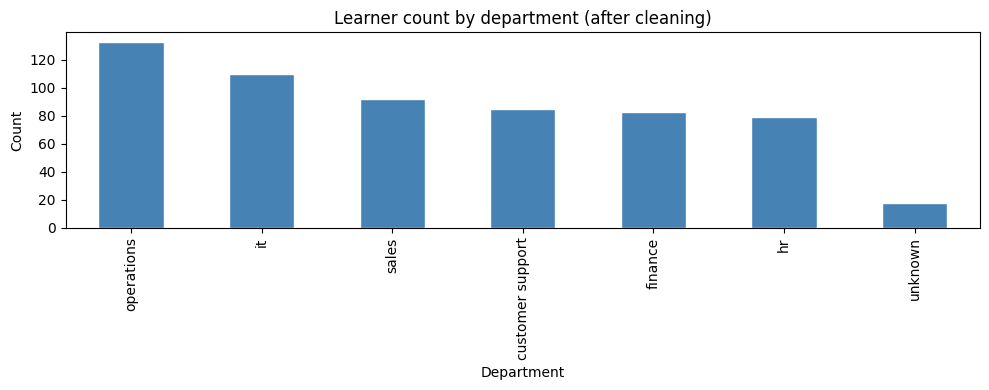

In [43]:
import matplotlib.pyplot as plt

df['department'].value_counts().plot(kind='bar', figsize=(10, 4), color='steelblue', edgecolor='white')
plt.title('Learner count by department (after cleaning)')
plt.ylabel('Count')
plt.xlabel('Department')
plt.tight_layout()
plt.savefig('visuals/department_distribution.png', dpi=150)
plt.show()

In [44]:
df.to_csv('cleaned_session_03_dataset.csv', index=False)
print('Saved!')

Saved!
